In [46]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 


## 📊 Dataset Information

The dataset contains the following features:

- age: Age of the individual
- gender: Male / Female
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status
- region: Residential area
- charges: Insurance cost (Target variable)

In [ ]:
#  Load the dataset 
df=pd.read_csv('insurance.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [4]:
df.shape

(1340, 10)

In [5]:
pd.set_option("display.float_format","{:.2f}".format)

In [6]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [7]:
df.duplicated().sum()

0

In [8]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


## 🔍 Exploratory Data Analysis (EDA)

In this section, we analyze:
- Distribution of features
- Relationship between BMI and insurance charges
- Impact of smoking on insurance cost
- Correlation between variables
- Outlier detection

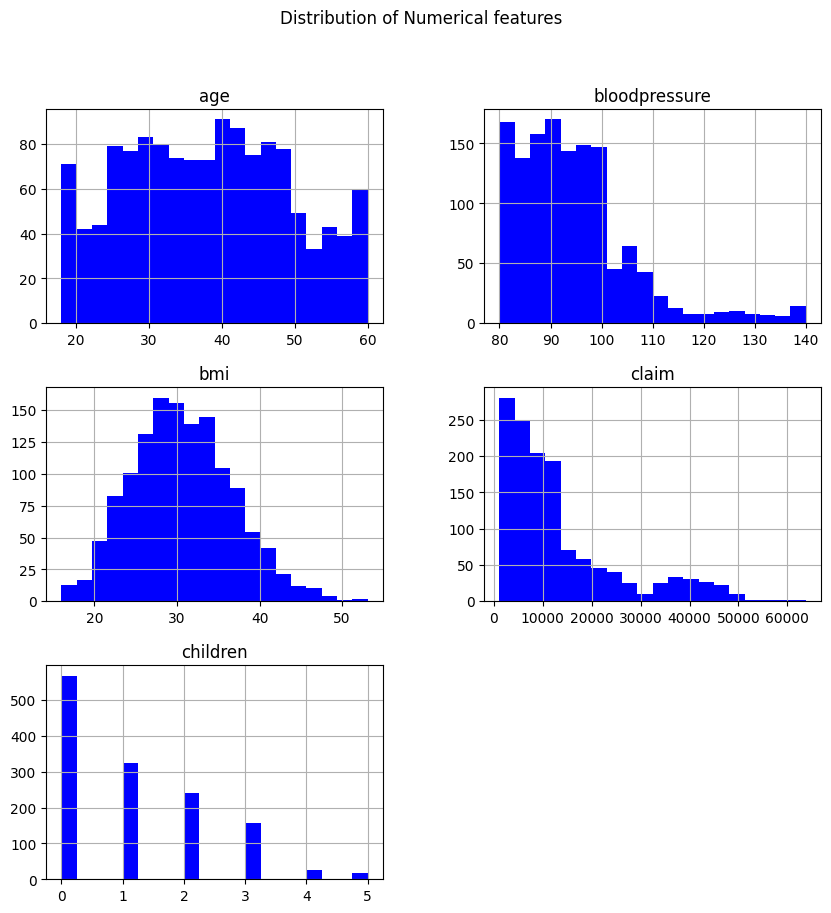

In [11]:
numerical_features=['age', 'bloodpressure', 'bmi', 'claim', 'children']
df[numerical_features].hist(bins=20 , figsize=(10,10), color='blue')
plt.suptitle('Distribution of Numerical features')
plt.show()

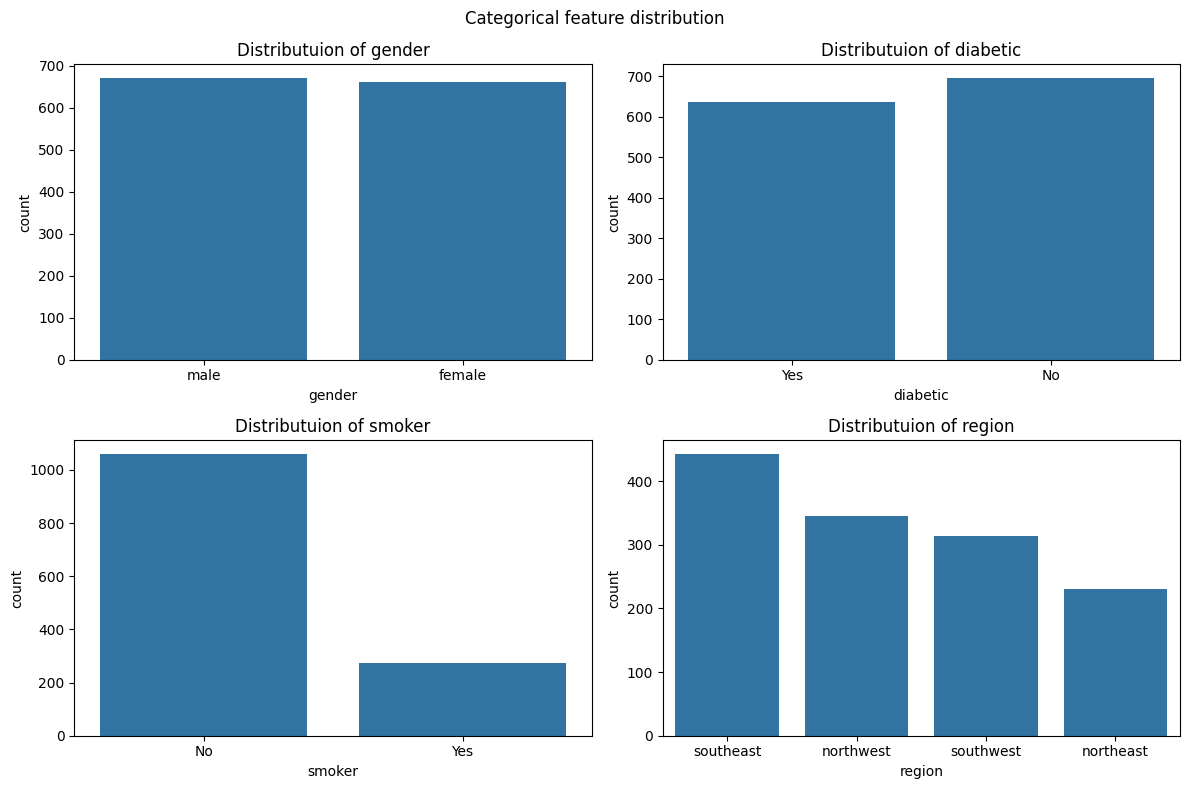

In [12]:
cat_features=['gender','diabetic' ,'smoker','region']
plt.figure(figsize=(12,8))
plt.suptitle('Categorical feature distribution')

for i,col in enumerate(cat_features,1):
    plt.subplot(2,2,i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distributuion of {col}")

plt.tight_layout()
plt.show()

In [13]:
df.groupby(['gender','smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

Text(0.5, 1.0, 'Average insurance claim by gender and smoker')

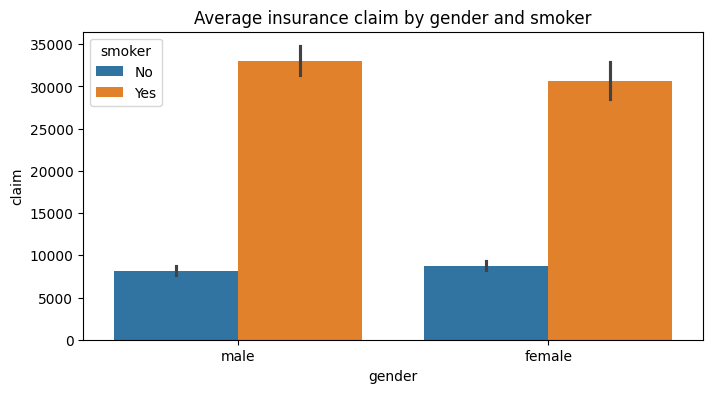

In [14]:
plt.figure(figsize=(8,4))
sns.barplot(data=df,x="gender",y="claim", hue="smoker", estimator=np.mean) 
plt.title("Average insurance claim by gender and smoker")

In [15]:
pivot_region_diabetic= df.groupby(['region','diabetic'])['claim'].mean().round(2).unstack()

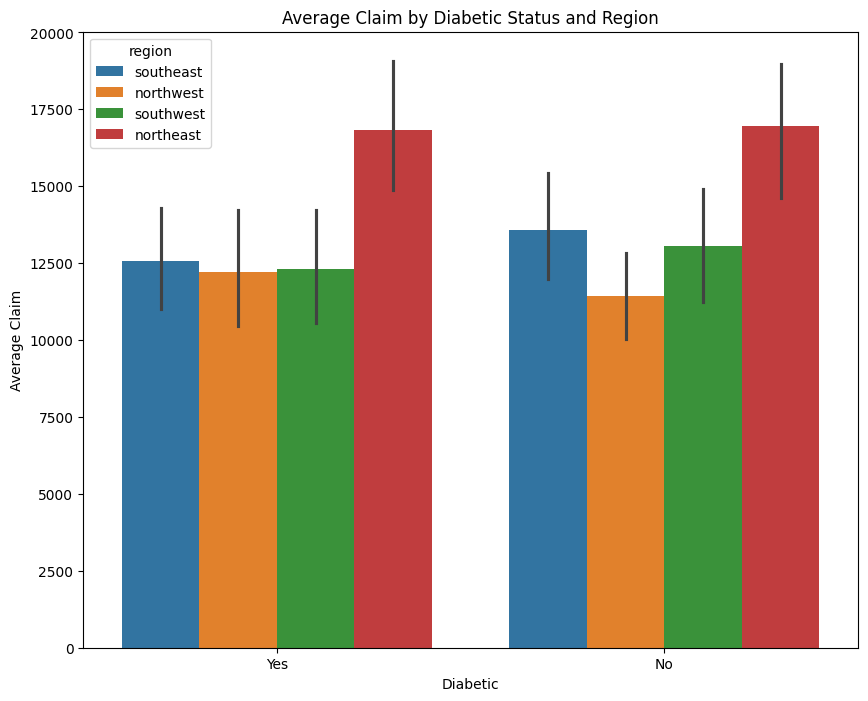

In [16]:
plt.figure(figsize=(10,8))
sns.barplot(df, x='diabetic', y='claim', hue='region', estimator=np.mean)
plt.title('Average Claim by Diabetic Status and Region')
plt.xlabel('Diabetic')
plt.ylabel('Average Claim')
plt.show()

<Axes: xlabel='region'>

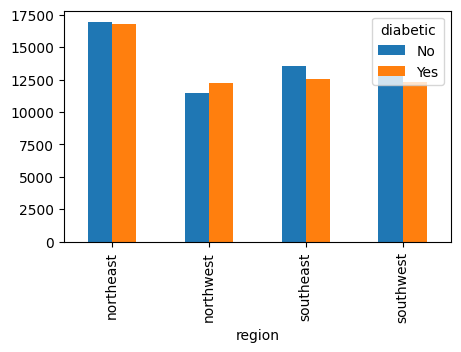

In [17]:
pivot_region_diabetic.plot(kind='bar',figsize=(5,3))

In [18]:
pivot_table_df= pd.pivot_table(df, index="region", values="claim", columns="smoker" ,  aggfunc="mean" )
pivot_table_df

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [19]:
print("Numeric columns", numerical_features)
print("Categorical columns", cat_features)

Numeric columns ['age', 'bloodpressure', 'bmi', 'claim', 'children']
Categorical columns ['gender', 'diabetic', 'smoker', 'region']


Text(0.5, 1.0, 'Correlation Heatmap')

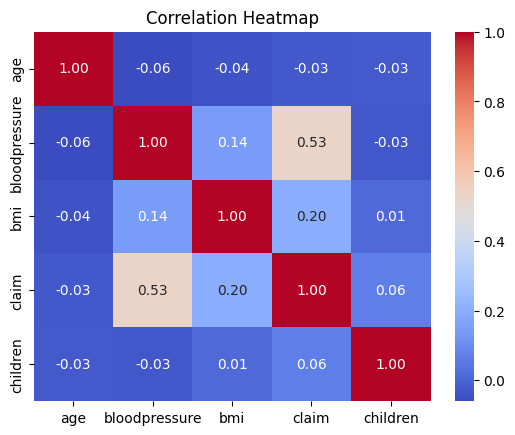

In [20]:
sns.heatmap(df[numerical_features].corr(),annot=True, cmap='coolwarm' , fmt=".2f")
plt.title("Correlation Heatmap")


Text(0.5, 1.0, 'Claim vs Age by Smoker and gender')

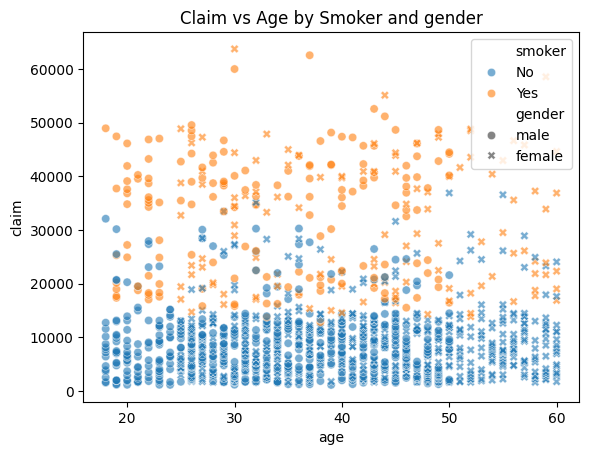

In [ ]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.6)
plt.title("Claim vs Age by Smoker and gender")


Text(0.5, 1.0, 'Relationship between BMI and Claim amount')

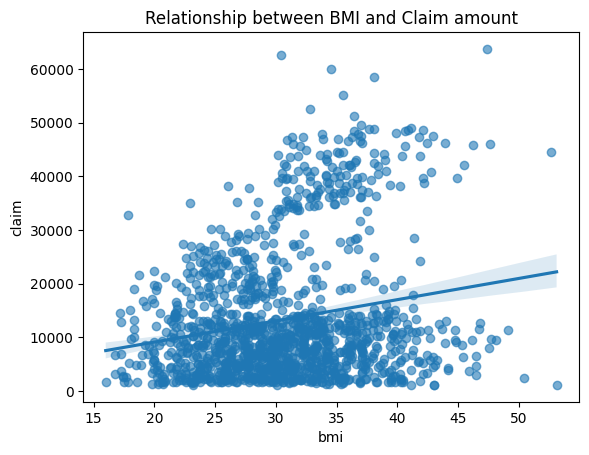

In [22]:
sns.regplot(data=df,x="bmi", y="claim", scatter_kws={'alpha': 0.6})
plt.title("Relationship between BMI and Claim amount")

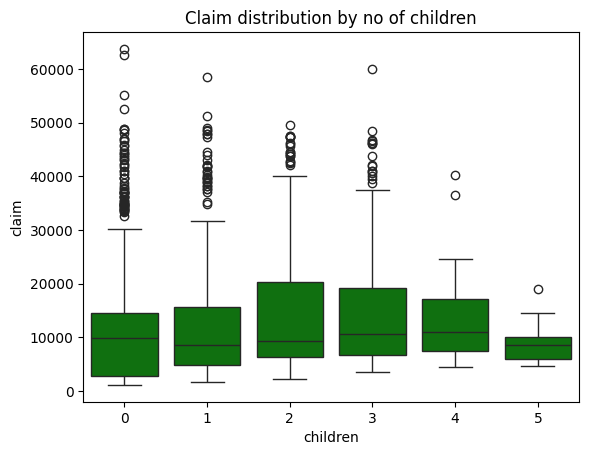

In [23]:
sns.boxplot(df, x='children', y='claim', color='green')
plt.title('Claim distribution by no of children')
plt.show()

In [24]:
df['age_group']=pd.cut(df['age'], bins=[0,18,30,45,60,100] , labels=["<18" , "18-30" , "30-45" , "45-60" ,"60-100"])
df["age_group"].value_counts()

age_group
30-45     553
45-60     383
18-30     380
<18        16
60-100      0
Name: count, dtype: int64

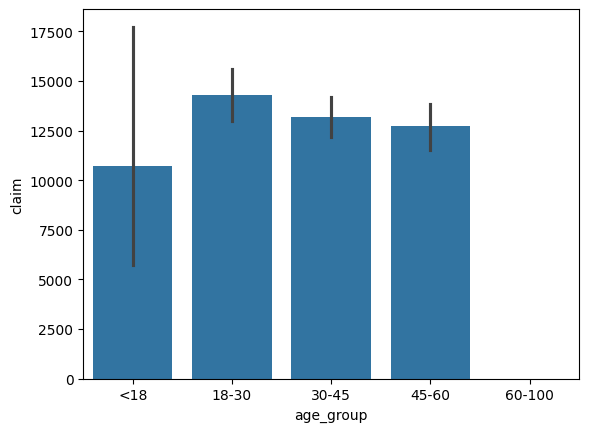

In [25]:
sns.barplot(data=df, x='age_group', y='claim', estimator=np.mean)
plt.show()

In [26]:
df['bmi_category']=pd.cut(df['bmi'], bins=[0,18.5,24.9,29.9,100] , labels=['Underweight','Normal', 'Overweight' ,'Obesity'])
df['bmi_category'].value_counts()

bmi_category
Obesity        702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

Text(0.5, 1.0, 'Claim distribution by BMI Category and Smoker')

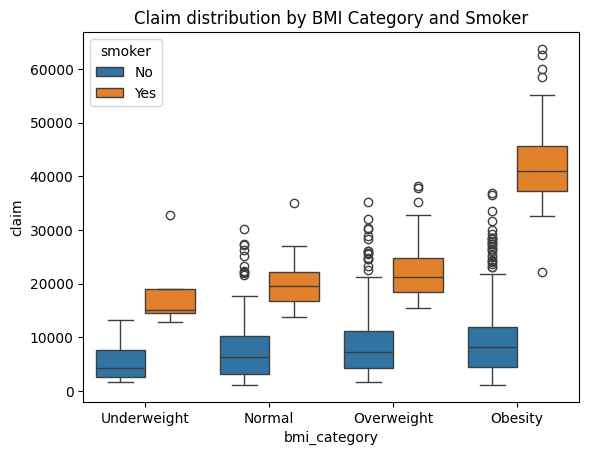

In [27]:
sns.boxplot(df, x='bmi_category', y='claim', hue='smoker')
plt.title("Claim distribution by BMI Category and Smoker")

In [28]:
import warnings 
warnings.filterwarnings("ignore")

In [29]:
region_stats=df.groupby("region").agg(
    smoker_rate=("smoker", lambda x: (x=='Yes').mean() *100),
    mean_claim=("claim", "mean")
).reset_index()

In [30]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


Text(0.5, 1.0, 'Smoker rate and avergae claim')

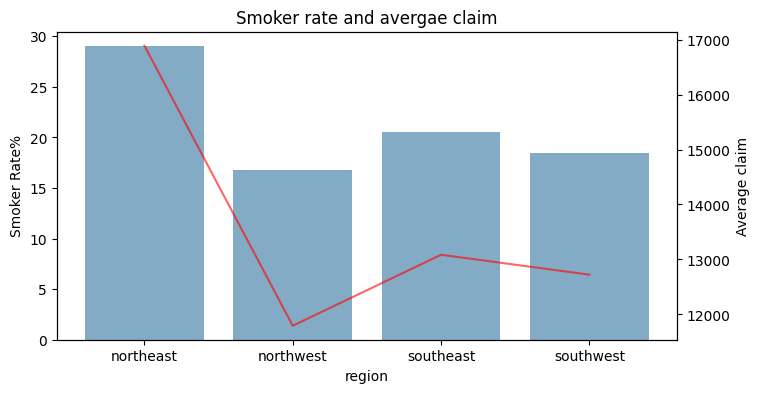

In [31]:
fig,ax1= plt.subplots(figsize=(8,4))

sns.barplot(region_stats, x='region' ,y='smoker_rate', ax=ax1 , alpha=0.6)
ax2=ax1.twinx()
sns.lineplot(region_stats, x='region', y="mean_claim" ,ax=ax2, color='red', alpha=0.6)

ax1.set_ylabel("Smoker Rate%")
ax2.set_ylabel("Average claim")
plt.title("Smoker rate and avergae claim")

## ⚙️ Data Preprocessing

Steps performed:
- Handling categorical variables using Label Encoding
- Feature scaling using StandardScaler
- Train-test split
- Preparing data for machine learning models

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler 
import pickle
import joblib

In [33]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [34]:
X=df[["age", "gender", "bmi","children","bloodpressure","diabetic","smoker"]]
Y=df["claim"]

In [38]:
X

,age,gender,bmi,children,bloodpressure,diabetic,smoker
0,39.00,1,23.20,0,91,1,0
1,24.00,1,30.10,0,87,0,0
7,19.00,1,41.10,0,100,0,0
8,20.00,1,43.00,0,86,0,0
9,30.00,1,53.10,0,97,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,0,88,1,1
1336,59.00,0,38.10,1,120,0,1
1337,30.00,1,34.50,3,91,1,1
1338,37.00,1,30.40,0,106,0,1


In [36]:
cat_cols=["gender","smoker","diabetic"]
label_encoders={}

In [37]:
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    
    X[col] = le.fit_transform(X[col].astype(str))
    
    label_encoders[col] = le
    
    joblib.dump(le, f"label_encoder_{col}.pkl")

In [39]:
label_encoders

{'gender': LabelEncoder(),
 'smoker': LabelEncoder(),
 'diabetic': LabelEncoder()}

In [40]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2
)

In [44]:
num_cols = ["age", "bmi", "bloodpressure", "children"]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [100]:
joblib.dump(scalar,"scalar.pkl")

NameError: name 'scalar' is not defined

In [42]:
print(X_train.shape, Y_train.shape, X_test.shape ,Y_test.shape)

(1065, 7) (1065,) (267, 7) (267,)


## 🧠 Model Training

Multiple regression models were trained:

- Linear Regression
- Polynomial Regression
- Random Forest Regressor
- Support Vector Regressor (SVR)
- XGBoost Regressor

Models were compared based on R² score and error metrics.

In [47]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [48]:
def evalute_model(model, X_train,X_test,Y_train,Y_test):
    y_pred=model.predict(X_test)
    r2=r2_score(Y_test,y_pred)
    mae=mean_absolute_error(Y_test,y_pred)
    mse=mean_squared_error(Y_test,y_pred)
    rmse=np.sqrt(mse)
    return {"R2": r2, "MAE": mae , "MSE": mse, "RMSE": rmse}

In [49]:
result={}

In [82]:
# Linear regression 
lr=LinearRegression()
lr.fit(X_train,Y_train)
result['LinearRegression']= evalute_model(lr,X_train,X_test,Y_train,Y_test)
print("Linear Regression Model trained")

#  Polynomial Regression 
best_poly_model=None
best_poly_score=-np.inf 

for degree in [2,3]:
    poly=PolynomialFeatures(degree=degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)

    poly_lr=LinearRegression()
    poly_lr.fit(X_train_poly,Y_train)

    score=poly_lr.score(X_test_poly,Y_test)

    if score> best_poly_score:
        best_poly_score=score 
        best_poly_model = (degree, poly, poly_lr)

degree, poly , poly_lr= best_poly_model

result[f"Polynomial Regression (deg){degree}"]=evalute_model(poly_lr,poly.fit_transform(X_train),poly.transform(X_test),Y_train,Y_test)

print("Polynomial Regression Model is trained")

# Random forest regression 

rf=RandomForestRegressor()
rf_params= {
    "n_estimators": [100,200],
    "max_depth" : [None, 10, 20], 
    "min_samples_split": [2,5], 
    "min_samples_leaf": [1,2],

}

rf_grid=GridSearchCV(rf,rf_params,cv=3, scoring='r2', n_jobs=-1, verbose=0)
rf_grid.fit(X_train,Y_train)
best_rf=rf_grid.best_estimator_

result["Random Forest"]=evalute_model(best_rf, X_train, X_test, Y_train, Y_test)


print("RandomForest Regression Model is trained , best parameters are", rf_grid.best_params_)

svr=SVR()

svr_params={
    "kernel":["rbf","poly","linear"], 
    "C": [1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3] 
}

svr_grid=GridSearchCV(svr ,svr_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
svr_grid.fit(X_train,Y_train)
svr_rf=svr_grid.best_estimator_
result["SVR Model"]=evalute_model(svr_rf, X_train,X_test,Y_train,Y_test )

print("SVR Regression Model is trained , best parameters are", svr_grid.best_params_)

xgb=XGBRegressor()
xgb_params={
     "n_estimators": [100,200], 
     "max_depth": [3,5,7],
     "learning_rate": [0.01,0.05,0.1], 
     "subsample":[0.8,1.0]
}

xgb_grid=GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs=-1,  verbose=0)
xgb_grid.fit(X_train,Y_train)
best_xgb=xgb_grid.best_estimator_

result["XGB Model"]=evalute_model(best_xgb, X_train,X_test,Y_train,Y_test)
print("XGB  Model is trained , best parameters are", xgb_grid.best_params_)


Linear Regression Model trained
Polynomial Regression Model is trained
RandomForest Regression Model is trained , best parameters are {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
SVR Regression Model is trained , best parameters are {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGB  Model is trained , best parameters are {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [83]:
result

{'LinearRegression': {'R2': 0.6544886717073068,
  'MAE': 5181.1539261255675,
  'MSE': 47546534.553611524,
  'RMSE': 6895.399520956818},
 'Polynomial Regression (deg)2': {'R2': 0.7493693158737,
  'MAE': 4321.34434008703,
  'MSE': 34489811.20790194,
  'RMSE': 5872.802670608126},
 'Random Forest': {'R2': 0.7857073278364568,
  'MAE': 4134.575415972263,
  'MSE': 29489261.587910514,
  'RMSE': 5430.40160466153},
 'SVR Model': {'R2': 0.43718861392638597,
  'MAE': 5582.496793214741,
  'MSE': 77449648.7491319,
  'RMSE': 8800.548207306856},
 'XGB Model': {'R2': 0.7971086561909114,
  'MAE': 3968.177607019545,
  'MSE': 27920301.01217238,
  'RMSE': 5283.966409069269},
 'Polynomial Regression (deg 2)': {'R2': 0.7493693158737,
  'MAE': 4321.34434008703,
  'MSE': 34489811.20790194,
  'RMSE': 5872.802670608126}}

In [88]:
results_df = pd.DataFrame(result).T.sort_values('RMSE', ascending=True)

In [89]:
results_df

,R2,MAE,MSE,RMSE
XGB Model,0.80,3968.18,27920301.01,5283.97
Random Forest,0.79,4134.58,29489261.59,5430.40
Polynomial Regression (deg)2,0.75,4321.34,34489811.21,5872.80
Polynomial Regression (deg 2),0.75,4321.34,34489811.21,5872.80
LinearRegression,0.65,5181.15,47546534.55,6895.40
SVR Model,0.44,5582.50,77449648.75,8800.55


In [91]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression (deg 2)": poly_lr, 
    "Random Forest Regressor": best_rf,
    "SVR Model": svr_rf,
    "XGB Model": best_xgb
}

In [90]:
best_model_name = results_df.index[0]
print("Best Model:", best_model_name)

Best Model: XGB Model


## 🏆 Best Model Selection

After evaluation, the best performing model was:

✔ XGBoost Regressor

This model provided the best balance between accuracy and error reduction.

In [92]:
best_model = models[best_model_name]

In [93]:
print("\n🏆 BEST MODEL REPORT")
print("Model:", best_model_name)
print(results_df.loc[best_model_name])


🏆 BEST MODEL REPORT
Model: XGB Model
R2            0.80
MAE        3968.18
MSE    27920301.01
RMSE       5283.97
Name: XGB Model, dtype: float64


In [94]:
import joblib

joblib.dump(best_model, "best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [95]:
print(scaler.feature_names_in_)

['age' 'bmi' 'bloodpressure' 'children']


In [99]:
import xgboost
print(xgboost.__version__)

3.1.2


In [101]:
import joblib
model = joblib.load("best_model.pkl")

In [102]:
model.save_model("model.json")